In [22]:
# CELL 1: Imports
import os
import random
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt
%matplotlib inline

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("Libraries loaded successfully!")

Device: cuda
Libraries loaded successfully!


In [2]:
# CELL 2: Stage 1 Preprocessing Logic
def stage1_preprocess(input_path, output_name):
    """
    Reads TIFF or ESRI Grid, applies 2% stretch, and saves as 8-bit.
    Skips processing if the output file already exists.
    """
    output_file = f"{output_name}_stretched.tif"
    
    # SAFEGUARD: Check if file already exists
    if os.path.exists(output_file):
        print(f"⏩ Skipped {output_name}: '{output_file}' already exists.")
        return output_file

    try:
        with rasterio.open(input_path) as src:
            data = src.read(1).astype('float32')
            nodata = src.nodata if src.nodata is not None else 0
            data[data == nodata] = np.nan

            # 2% Cumulative Stretch
            p2, p98 = np.nanpercentile(data, (2, 98))
            
            stretched = (data - p2) / (p98 - p2) * 255
            stretched = np.clip(stretched, 0, 255).astype('uint8')
            stretched[np.isnan(data)] = 0

            meta = src.meta.copy()
            meta.update({
                "driver": "GTiff",
                "dtype": "uint8",
                "count": 1,
                "nodata": 0
            })

            with rasterio.open(output_file, "w", **meta) as dst:
                dst.write(stretched, 1)
            
            print(f"✅ Processed {output_name}: Saved as '{output_file}'")
            return output_file

    except Exception as e:
        print(f"❌ Error processing {input_path}: {e}")
        return None

In [3]:
# CELL 3: Run Stage 1
# FIX: Use relative paths from the Project/ folder (works on any machine)
datasets = {
    "Cartosat_Main": os.path.join("Monocromatic", "CARTOSAT_1M_PAN.tif"),
    "Cartosat_Grid": os.path.join("Monocromatic", "cartosat.ovr"),
    "IRS_ID_Grid"  : os.path.join("Monocromatic", "IRS_ID.ovr"),
}

stretched_files = []

for name, path in datasets.items():
    if os.path.exists(path):
        out_path = stage1_preprocess(path, name)
        if out_path:
            stretched_files.append(out_path)
    else:
        print(f"Path not found: {path}")

print(f"\nReady files: {stretched_files}")

⏩ Skipped Cartosat_Main: 'Cartosat_Main_stretched.tif' already exists.
⏩ Skipped Cartosat_Grid: 'Cartosat_Grid_stretched.tif' already exists.
⏩ Skipped IRS_ID_Grid: 'IRS_ID_Grid_stretched.tif' already exists.

Ready files: ['Cartosat_Main_stretched.tif', 'Cartosat_Grid_stretched.tif', 'IRS_ID_Grid_stretched.tif']


In [4]:
# CELL 4: Stage 2 Tiling Logic
def create_patches(input_tiff, output_dir, patch_size=256, stride=128, empty_threshold=0.5):
    """
    Slices a large TIFF into overlapping PNG patches.
    Skips patches that already exist in the output directory.
    """
    os.makedirs(output_dir, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(input_tiff))[0]

    with rasterio.open(input_tiff) as src:
        img = src.read(1)
        height, width = img.shape
        
        patch_count = 0
        skipped_empty = 0
        skipped_existing = 0

        for y in range(0, height - patch_size + 1, stride):
            for x in range(0, width - patch_size + 1, stride):
                patch_filename = os.path.join(output_dir, f"{base_name}_{y}_{x}.png")
                
                # SAFEGUARD: Skip if this specific patch already exists
                if os.path.exists(patch_filename):
                    skipped_existing += 1
                    continue
                
                patch = img[y:y+patch_size, x:x+patch_size]
                
                # Discard patches that are mostly black (NoData)
                zero_ratio = np.sum(patch == 0) / (patch_size * patch_size)
                if zero_ratio > empty_threshold:
                    skipped_empty += 1
                    continue
                
                patch_img = Image.fromarray(patch)
                patch_img.save(patch_filename)
                patch_count += 1

        print(f"Done '{base_name}': Generated {patch_count} new. (Skipped {skipped_existing} existing, {skipped_empty} empty)")

In [5]:
# CELL 5: Run Stage 2
output_folder = "training_patches"

for file in stretched_files:
    if os.path.exists(file):
        print(f"Tiling {file}...")
        create_patches(file, output_folder, patch_size=256, stride=128)

Tiling Cartosat_Main_stretched.tif...
Done 'Cartosat_Main_stretched': Generated 0 new. (Skipped 6493 existing, 206 empty)
Tiling Cartosat_Grid_stretched.tif...
Done 'Cartosat_Grid_stretched': Generated 0 new. (Skipped 775 existing, 0 empty)
Tiling IRS_ID_Grid_stretched.tif...
Done 'IRS_ID_Grid_stretched': Generated 0 new. (Skipped 49 existing, 175 empty)


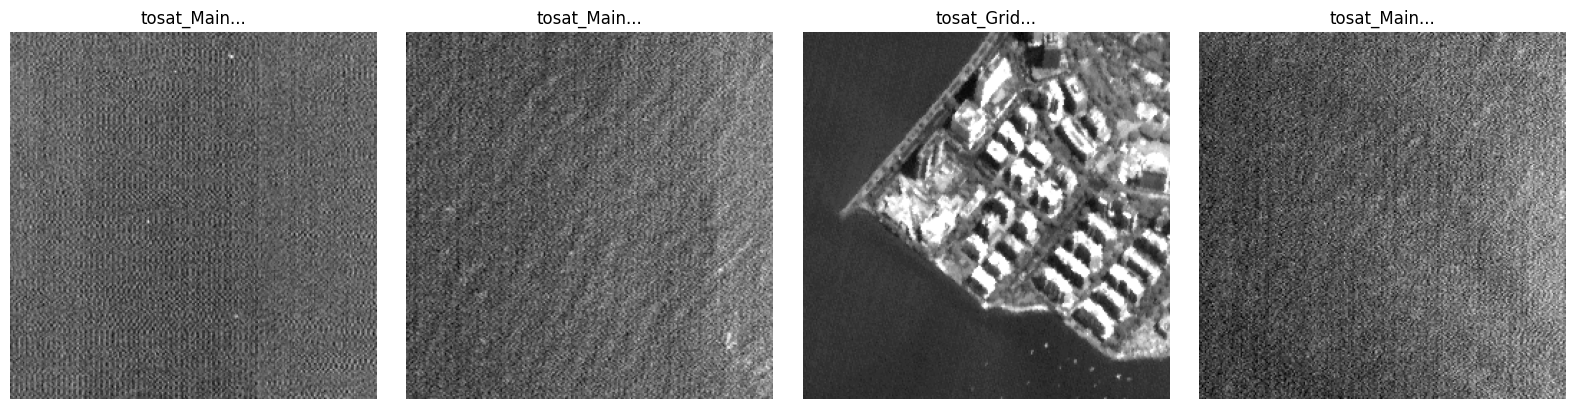

In [6]:
# CELL 6: Visualize Random Patches
import random

if os.path.exists(output_folder):
    all_patches = [f for f in os.listdir(output_folder) if f.endswith('.png')]
    
    if len(all_patches) >= 4:
        # Pick 4 random patches
        sample_patches = random.sample(all_patches, 4)
        
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        for i, patch_name in enumerate(sample_patches):
            img_path = os.path.join(output_folder, patch_name)
            img = Image.open(img_path)
            
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(patch_name.split('_stretched')[0][-10:] + '...')
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough patches to display. Did the tiling complete successfully?")
else:
    print(f"Folder '{output_folder}' does not exist.")

In [7]:
# CELL 7: Center Cropped Dataloader
# FIX: use output_folder (defined in Cell 5) — patch_folder was never defined
import glob

PATCH_FOLDER = "training_patches"   # consistent name used from here onward
CROP_SIZE    = 96                   # center crop to avoid black borders

class SatellitePatchDataset(Dataset):
    def __init__(self, patch_dir):
        self.image_paths = sorted(glob.glob(f"{patch_dir}/*.png"))  # sorted for reproducibility
        self.transform = transforms.Compose([
            transforms.CenterCrop(CROP_SIZE),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("L")
        return self.transform(image), self.transform(image)


dataset = SatellitePatchDataset(PATCH_FOLDER)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

print(f"Total patches loaded : {len(dataset)}")
print(f"Patch folder         : {PATCH_FOLDER}")
print(f"Center crop size     : {CROP_SIZE}x{CROP_SIZE}")

Total patches loaded : 7317
Patch folder         : training_patches
Center crop size     : 96x96


In [8]:
# CELL 8: The Autoencoder Model
class UNetAutoencoder(nn.Module):
    def __init__(self):
        super(UNetAutoencoder, self).__init__()
        
        # ENCODER (Compressing the image)
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2) # Reduces 256x256 to 128x128
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2) # Reduces 128x128 to 64x64
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2) # Reduces 64x64 to 32x32
        )
        
        # BOTTLENECK (The deepest features)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU()
        )
        
        # DECODER (Reconstructing the image)
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2), nn.ReLU() # Upscales to 64x64
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU() # Upscales to 128x128
        )
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU() # Upscales to 256x256
        )
        
        # FINAL LAYER (Outputting the 1-channel image)
        self.final_out = nn.Conv2d(32, 1, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid() # Keeps pixel values between 0 and 1

    def forward(self, x):
        # Encode
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        
        # Bottleneck
        b = self.bottleneck(x3)
        
        # Decode
        d1 = self.dec1(b)
        d2 = self.dec2(d1)
        d3 = self.dec3(d2)
        
        out = self.sigmoid(self.final_out(d3))
        return out

# Check for GPU (CUDA) or Apple Silicon (MPS), fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model = UNetAutoencoder().to(device)

Using device: cuda


In [9]:
# CELL 9: Training Loop
num_epochs = 25 # Start with 5 epochs to see if it works, then increase to 20+
criterion = nn.MSELoss() # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Starting Training...")

for epoch in range(num_epochs):
    epoch_loss = 0.0
    
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 1. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # 2. Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("Training Complete!")
# Save the learned weights
torch.save(model.state_dict(), "satellite_autoencoder.pth")

Starting Training...
Epoch [1/25], Loss: 0.0195
Epoch [2/25], Loss: 0.0070
Epoch [3/25], Loss: 0.0063
Epoch [4/25], Loss: 0.0057
Epoch [5/25], Loss: 0.0057
Epoch [6/25], Loss: 0.0054
Epoch [7/25], Loss: 0.0052
Epoch [8/25], Loss: 0.0052
Epoch [9/25], Loss: 0.0050
Epoch [10/25], Loss: 0.0051
Epoch [11/25], Loss: 0.0049
Epoch [12/25], Loss: 0.0049
Epoch [13/25], Loss: 0.0047
Epoch [14/25], Loss: 0.0047
Epoch [15/25], Loss: 0.0047
Epoch [16/25], Loss: 0.0045
Epoch [17/25], Loss: 0.0048
Epoch [18/25], Loss: 0.0046
Epoch [19/25], Loss: 0.0044
Epoch [20/25], Loss: 0.0044
Epoch [21/25], Loss: 0.0045
Epoch [22/25], Loss: 0.0043
Epoch [23/25], Loss: 0.0044
Epoch [24/25], Loss: 0.0043
Epoch [25/25], Loss: 0.0043
Training Complete!


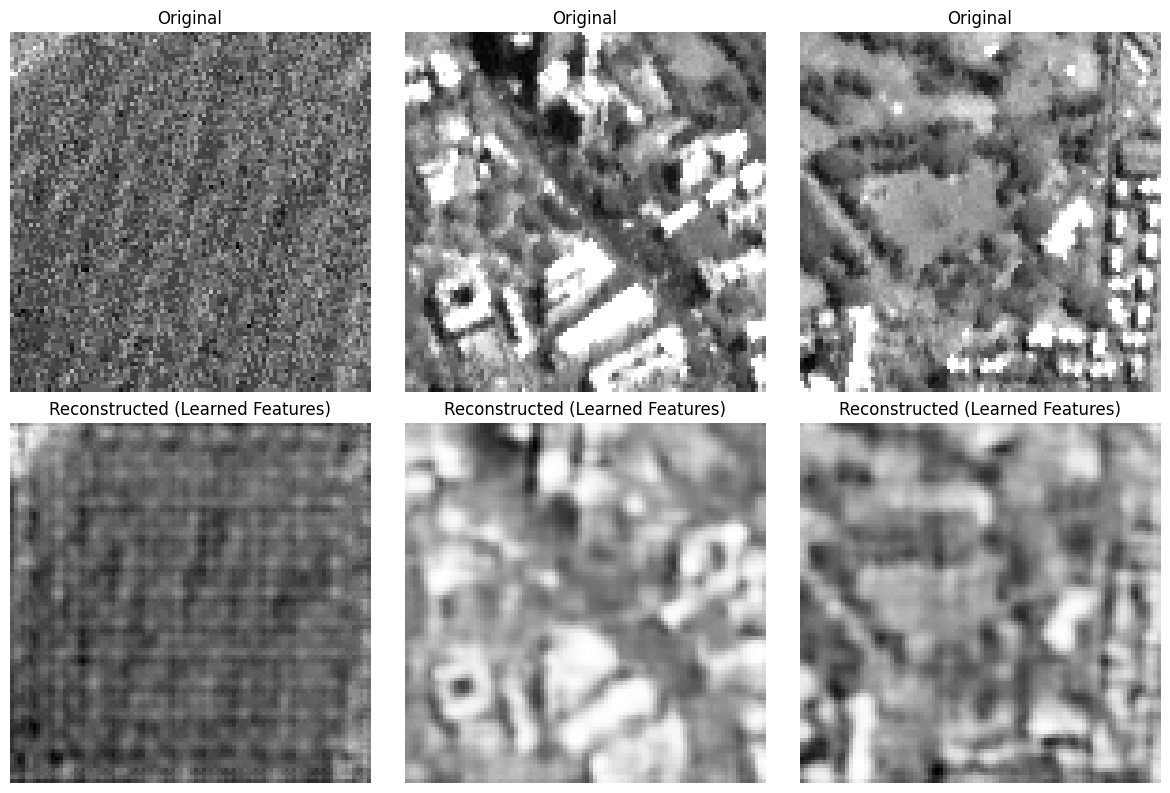

In [23]:
# CELL 10: Visualize the Results
model.eval() # Set to evaluation mode

# Get a single batch of images
dataiter = iter(dataloader)
images, _ = next(dataiter)
images = images.to(device)

# Reconstruct them
with torch.no_grad():
    reconstructions = model(images)

# Move back to CPU for matplotlib
images = images.cpu()
reconstructions = reconstructions.cpu()

# Plot first 3 images in the batch
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i in range(3):
    # Original Image (Top Row)
    axes[0, i].imshow(images[i][0].numpy(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    
    # Reconstructed Image (Bottom Row)
    axes[1, i].imshow(reconstructions[i][0].numpy(), cmap='gray')
    axes[1, i].set_title("Reconstructed (Learned Features)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# # CELL 11: Extracting Features
# import torch.nn as nn
# from sklearn.cluster import KMeans
# from sklearn.decomposition import PCA
# import numpy as np

# # 1. Create a Feature Extractor from our trained model
# class FeatureExtractor(nn.Module):
#     def __init__(self, trained_model):
#         super(FeatureExtractor, self).__init__()
#         # Copy the encoder and bottleneck from the trained model
#         self.enc1 = trained_model.enc1
#         self.enc2 = trained_model.enc2
#         self.enc3 = trained_model.enc3
#         self.bottleneck = trained_model.bottleneck
        
#         # Add Global Average Pooling to flatten the 256x32x32 map into 256 numbers
#         self.pool = nn.AdaptiveAvgPool2d((1, 1))

#     def forward(self, x):
#         x = self.enc1(x)
#         x = self.enc2(x)
#         x = self.enc3(x)
#         x = self.bottleneck(x)
#         x = self.pool(x)
#         return torch.flatten(x, 1) # Output: [Batch_Size, 256]

# feature_extractor = FeatureExtractor(model).to(device)
# feature_extractor.eval()

# print("Feature Extractor ready!")

In [26]:
# CELL 11: ResNet18 Feature Extraction on ALL patches
# FIX 1: removed max_images cap — was using only 1000/7317 patches
# FIX 2: deprecated pretrained=True → weights=ResNet18_Weights.DEFAULT
from sklearn.cluster import KMeans
import torchvision.models as models
import torchvision.transforms.functional as TF
from torchvision.models import ResNet18_Weights
from sklearn.decomposition import PCA
import numpy as np

# Load pretrained ResNet18, strip classifier head
resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
resnet = nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

# ImageNet normalization values
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

features_list = []

print(f"Extracting features from ALL {len(dataset)} patches...")
with torch.no_grad():
    for batch_idx, (inputs, _) in enumerate(dataloader):
        inputs = inputs.to(device)

        # 1-channel → 3-channel
        inputs_3ch = inputs.repeat(1, 3, 1, 1)

        # Apply ImageNet normalization per image in batch
        for i in range(inputs_3ch.size(0)):
            inputs_3ch[i] = TF.normalize(inputs_3ch[i], IMAGENET_MEAN, IMAGENET_STD)

        features = resnet(inputs_3ch)
        features = torch.flatten(features, 1)
        features_list.append(features.cpu().numpy())

        if (batch_idx + 1) % 50 == 0:
            done = (batch_idx + 1) * dataloader.batch_size
            print(f"  Processed {min(done, len(dataset))}/{len(dataset)} patches...")

X_features = np.vstack(features_list)
print(f"\nRaw feature matrix : {X_features.shape}")

# PCA to 50 dimensions
pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_features)
print(f"After PCA          : {X_pca.shape}")
print(f"Variance explained : {pca.explained_variance_ratio_.sum()*100:.1f}%")

Extracting features from ALL 7317 patches...
  Processed 800/7317 patches...
  Processed 1600/7317 patches...
  Processed 2400/7317 patches...
  Processed 3200/7317 patches...
  Processed 4000/7317 patches...
  Processed 4800/7317 patches...
  Processed 5600/7317 patches...
  Processed 6400/7317 patches...
  Processed 7200/7317 patches...

Raw feature matrix : (7317, 512)
After PCA          : (7317, 50)
Variance explained : 83.1%


In [13]:
# # CELL 12: Generate Vectors for Clustering
# features_list = []
# image_paths_list = []

# # We'll just use a subset to speed up the clustering process for now
# max_images_to_cluster = 1000 
# count = 0

# print("Extracting features...")
# with torch.no_grad():
#     for inputs, _ in dataloader:
#         inputs = inputs.to(device)
#         features = feature_extractor(inputs)
        
#         # Move to CPU and convert to numpy for Scikit-Learn
#         features_list.append(features.cpu().numpy())
#         count += inputs.size(0)
        
#         if count >= max_images_to_cluster:
#             break

# # Concatenate all batches into one giant matrix
# X_features = np.vstack(features_list)

# # Optional but highly recommended: PCA to reduce noise before K-Means
# pca = PCA(n_components=50)
# X_pca = pca.fit_transform(X_features)

# print(f"Extracted features for {X_pca.shape[0]} images.")
# print(f"Feature vector shape per image: {X_pca.shape[1]}")

In [27]:
# CELL 13: K-Means Clustering
num_clusters =6 # You can change this to 4 or 5 depending on your terrain

print(f"Running K-Means to find {num_clusters} classes...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
pseudo_labels = kmeans.fit_predict(X_pca)

print("Clustering complete! Pseudo-labels generated.")

Running K-Means to find 6 classes...
Clustering complete! Pseudo-labels generated.


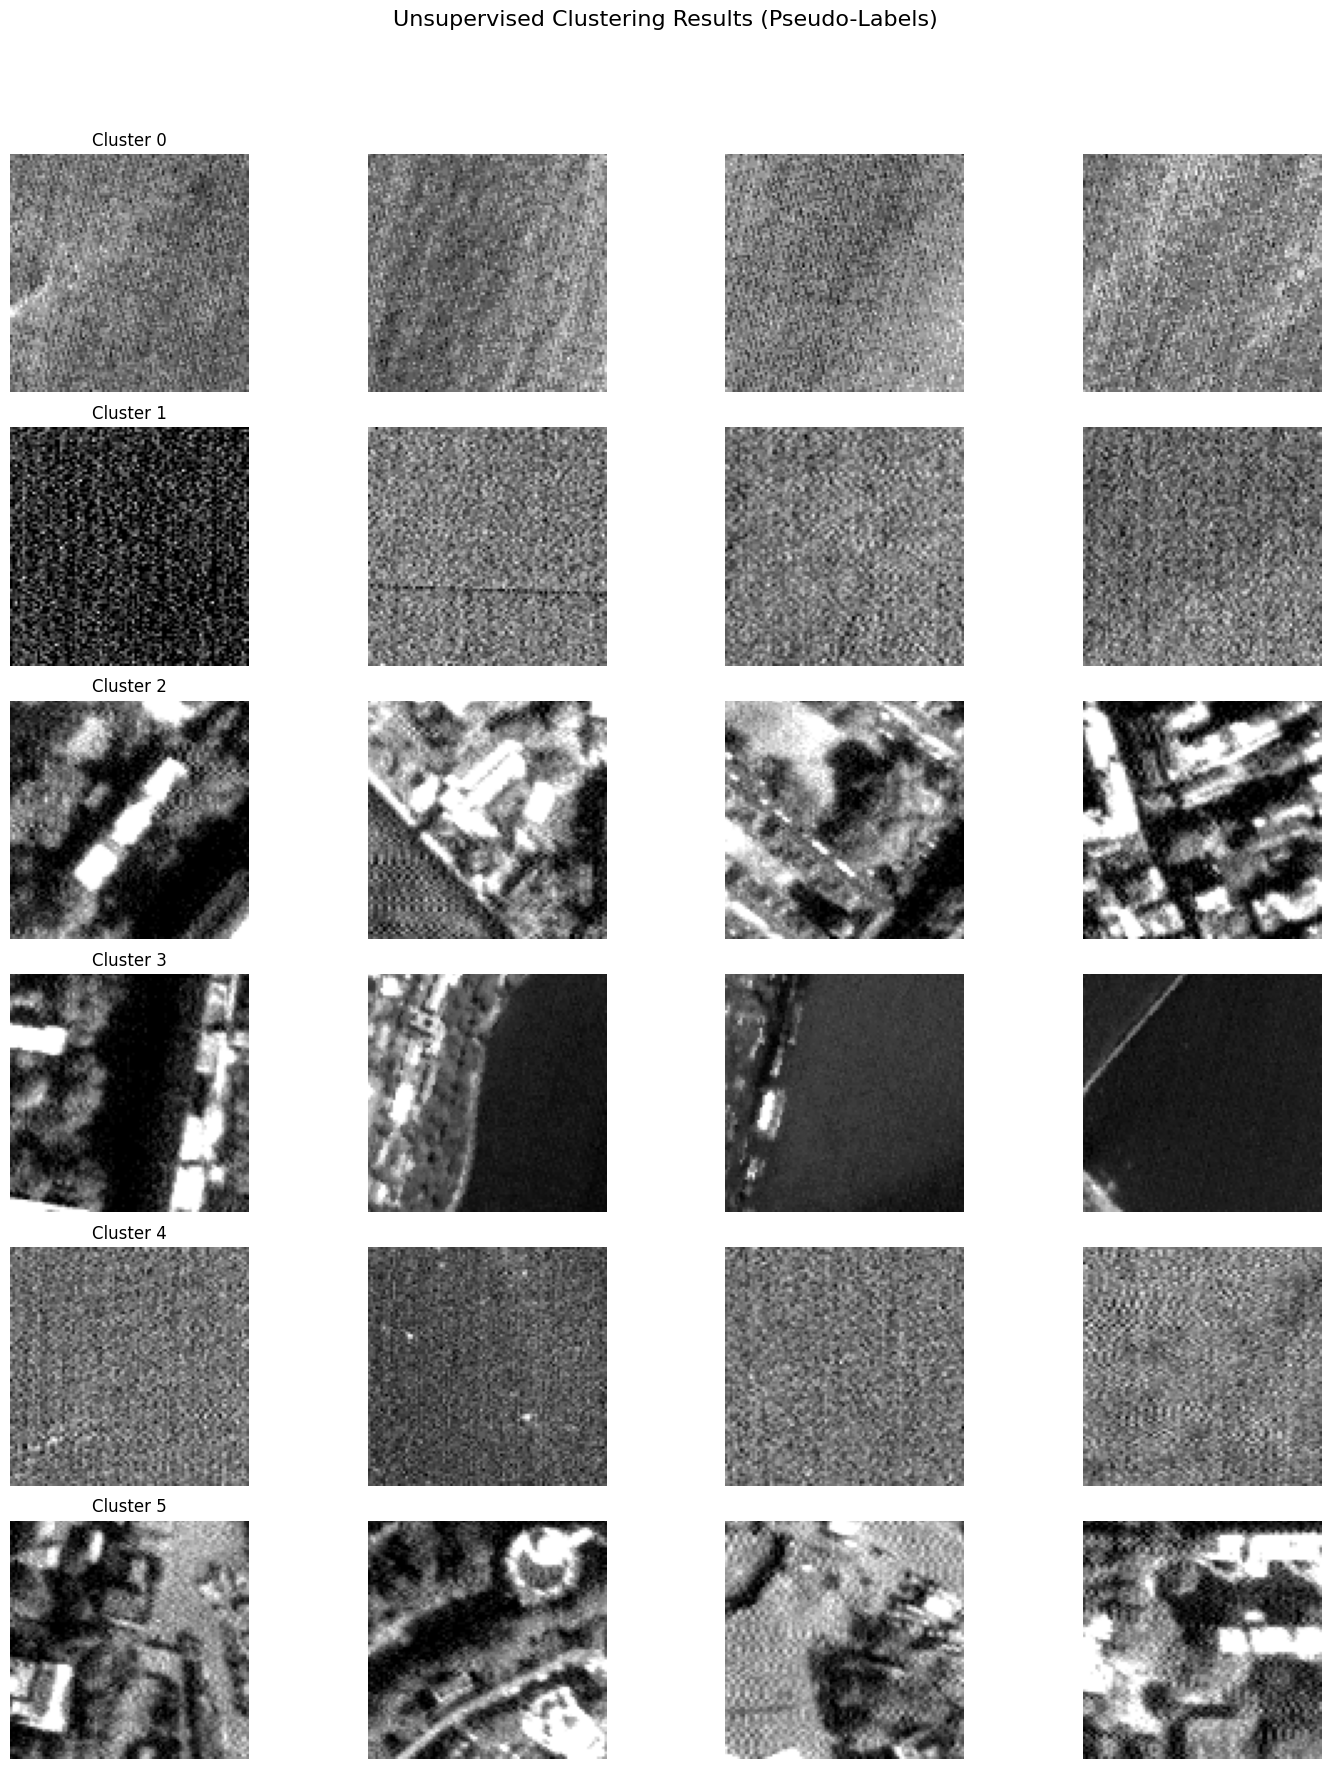

In [28]:
# CELL 14: Visualize the Clusters
import random
import matplotlib.pyplot as plt

# We need the original image paths corresponding to our dataloader
# Since dataloader shuffles by default, we will just grab the images directly from the dataset 
# for visualization purposes, matching the indices of our generated labels.

fig, axes = plt.subplots(num_clusters, 4, figsize=(15, 3 * num_clusters))
fig.suptitle("Unsupervised Clustering Results (Pseudo-Labels)", fontsize=16)

for cluster_id in range(num_clusters):
    # Find indices of images that belong to this cluster
    indices = np.where(pseudo_labels == cluster_id)[0]
    
    # Pick up to 4 random images from this cluster
    sample_indices = random.sample(list(indices), min(4, len(indices)))
    
    for j, idx in enumerate(sample_indices):
        # We fetch the image tensor from our dataset
        # Note: Since the dataloader shuffled, we reconstruct the matching using sequential load
        # For simplicity in this visualization, we'll just plot them
        img_tensor = dataset[idx][0] 
        img_np = img_tensor.squeeze().numpy()
        
        axes[cluster_id, j].imshow(img_np, cmap='gray')
        axes[cluster_id, j].axis('off')
        if j == 0:
            axes[cluster_id, j].set_title(f"Cluster {cluster_id}")

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

In [29]:
# CORRECTED CELL 15: Save Pseudo-Labels for 6 Clusters
import pandas as pd

# The 6 classes based on your clustering
class_names = {
    5: 'Bare_Earth_Exposed_Soil', # Change if Cluster 0 looks like something else
    4: 'Deep_Water_or_Shadows', 
    3: 'Urban_Built_Up',
    2: 'Roads_and_Pavement',
    0: 'Low_Vegetation_Fields',
    1: 'Beaches/Sea_Shores'  
}

# THE FIX: Slice the paths to the exact length of the generated labels
exact_count = len(pseudo_labels)
paths_clustered = dataset.image_paths[:exact_count]

print(f"Aligning {len(paths_clustered)} paths with {len(pseudo_labels)} labels...")

# Create a Pandas DataFrame
df_labels = pd.DataFrame({
    'image_path': paths_clustered,
    'cluster_id': pseudo_labels
})

# Add the human-readable class names
df_labels['class_name'] = df_labels['cluster_id'].map(class_names)

# Save to CSV
csv_filename = "cartosat_6_classes_labeled.csv"
df_labels.to_csv(csv_filename, index=False)

print(f"✅ Successfully saved {len(df_labels)} labels to {csv_filename}!")
display(df_labels.head(10))

Aligning 7317 paths with 7317 labels...
✅ Successfully saved 7317 labels to cartosat_6_classes_labeled.csv!


,image_path,cluster_id,class_name
0,training_patches\Cartosat_Grid_stretched_0_0.png,0,Low_Vegetation_Fields
1,training_patches\Cartosat_Grid_stretched_0_102...,3,Urban_Built_Up
2,training_patches\Cartosat_Grid_stretched_0_115...,3,Urban_Built_Up
3,training_patches\Cartosat_Grid_stretched_0_128...,0,Low_Vegetation_Fields
4,training_patches\Cartosat_Grid_stretched_0_128...,3,Urban_Built_Up
5,training_patches\Cartosat_Grid_stretched_0_140...,3,Urban_Built_Up
6,training_patches\Cartosat_Grid_stretched_0_153...,3,Urban_Built_Up
7,training_patches\Cartosat_Grid_stretched_0_166...,3,Urban_Built_Up
8,training_patches\Cartosat_Grid_stretched_0_179...,3,Urban_Built_Up
9,training_patches\Cartosat_Grid_stretched_0_192...,3,Urban_Built_Up


In [30]:
# CORRECTED CELL 16: Supervised Dataset and DataLoader
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# 1. Load the labels we generated
df = pd.read_csv("cartosat_6_classes_labeled.csv")

class SupervisedSatelliteDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe
        # Transforms including 3-channel ImageNet Normalization
        self.transform = transforms.Compose([
            transforms.CenterCrop(96),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['cluster_id']
        
        # THE FIX: Convert directly to "RGB". PIL will copy the grayscale to 3 channels automatically.
        image = Image.open(img_path).convert("RGB")
        
        # Now the transform (and its 3-channel normalization) will work perfectly
        tensor_image = self.transform(image)
        
        return tensor_image, torch.tensor(label, dtype=torch.long)

# 2. Create the Dataset
full_dataset = SupervisedSatelliteDataset(df)

# 3. Split into Train (80%) and Validation (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"✅ Loaded {len(full_dataset)} labeled images.")
print(f"Training on {train_size} images. Validating on {val_size} images.")

✅ Loaded 7317 labeled images.
Training on 5853 images. Validating on 1464 images.


In [31]:
# CELL 17: Define the ResNet18 Classifier
# FIX: deprecated pretrained=True → weights=ResNet18_Weights.DEFAULT
import torchvision.models as models
from torchvision.models import ResNet18_Weights

print("Setting up the ResNet18 classifier...")

# 1. Load pretrained ResNet18
classifier = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# 2. Freeze all base layers
for param in classifier.parameters():
    param.requires_grad = False

# 3. Replace final FC layer: 512 → num_classes
NUM_CLASSES = 6
num_ftrs = classifier.fc.in_features
classifier.fc = nn.Linear(num_ftrs, NUM_CLASSES)

# 4. Unfreeze the new final layer
for param in classifier.fc.parameters():
    param.requires_grad = True

classifier = classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.fc.parameters(), lr=1e-3)

print(f"Classifier ready — {NUM_CLASSES} classes")
print(f"Trainable params: {sum(p.numel() for p in classifier.parameters() if p.requires_grad)}")

Setting up the ResNet18 classifier...
Classifier ready — 6 classes
Trainable params: 3078


In [33]:
# CELL 18: Supervised Training Loop
# FIX 1: LR scheduler added (ReduceLROnPlateau)
# FIX 2: Best model checkpoint — saves on best val accuracy
# FIX 3: Model saved with full metadata needed by the UI

os.makedirs("models", exist_ok=True)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)

NUM_EPOCHS   = 10
best_val_acc = 0.0
history      = {'train_loss': [], 'train_acc': [], 'val_acc': []}

# Class names ordered by cluster ID (0-5)
CLASS_NAMES_ORDERED = [
    'Low_Vegetation_Fields',   # 0
    'Beaches_Sea_Shores',      # 1
    'Roads_and_Pavement',      # 2
    'Urban_Built_Up',          # 3
    'Deep_Water_or_Shadows',   # 4
    'Bare_Earth_Exposed_Soil', # 5
]

print("Starting Supervised Training...")

for epoch in range(NUM_EPOCHS):
    # ---- TRAIN ----
    classifier.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = classifier(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc  = 100 * correct / total
    avg_loss   = running_loss / len(train_loader)

    # ---- VALIDATION ----
    classifier.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, predicted = torch.max(classifier(inputs), 1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    scheduler.step(val_acc)

    history['train_loss'].append(avg_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(classifier.state_dict(), "models/cartosat_classifier_best.pth")

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] "
          f"Loss: {avg_loss:.4f}  Train Acc: {train_acc:.2f}%  Val Acc: {val_acc:.2f}%")

print(f"\nTraining Complete!  Best val acc: {best_val_acc:.2f}%")

# ---- Save full checkpoint with metadata for the UI ----
torch.save({
    'model_state_dict' : classifier.state_dict(),
    'model_type'       : 'resnet18_patch_classifier',
    'num_classes'      : NUM_CLASSES,
    'class_names'      : CLASS_NAMES_ORDERED,
    'crop_size'        : CROP_SIZE,
    'imagenet_mean'    : IMAGENET_MEAN,
    'imagenet_std'     : IMAGENET_STD,
    'data_type'        : 'panchromatic_1band',
    'best_val_acc'     : best_val_acc,
}, "models/cartosat_classifier_checkpoint.pth")

print("Saved: models/cartosat_classifier_best.pth")
print("Saved: models/cartosat_classifier_checkpoint.pth  (weights + metadata)")

Starting Supervised Training...
Epoch [ 1/10] Loss: 0.2945  Train Acc: 89.22%  Val Acc: 90.16%
Epoch [ 2/10] Loss: 0.2796  Train Acc: 89.68%  Val Acc: 90.57%
Epoch [ 3/10] Loss: 0.2614  Train Acc: 89.95%  Val Acc: 90.23%
Epoch [ 4/10] Loss: 0.2709  Train Acc: 89.95%  Val Acc: 90.30%
Epoch [ 5/10] Loss: 0.2443  Train Acc: 90.81%  Val Acc: 90.57%
Epoch [ 6/10] Loss: 0.2439  Train Acc: 91.03%  Val Acc: 90.44%
Epoch [ 7/10] Loss: 0.2396  Train Acc: 90.93%  Val Acc: 90.71%
Epoch [ 8/10] Loss: 0.2306  Train Acc: 91.27%  Val Acc: 90.44%
Epoch [ 9/10] Loss: 0.2276  Train Acc: 91.90%  Val Acc: 90.71%
Epoch [10/10] Loss: 0.2207  Train Acc: 91.95%  Val Acc: 91.05%

Training Complete!  Best val acc: 91.05%
Saved: models/cartosat_classifier_best.pth
Saved: models/cartosat_classifier_checkpoint.pth  (weights + metadata)


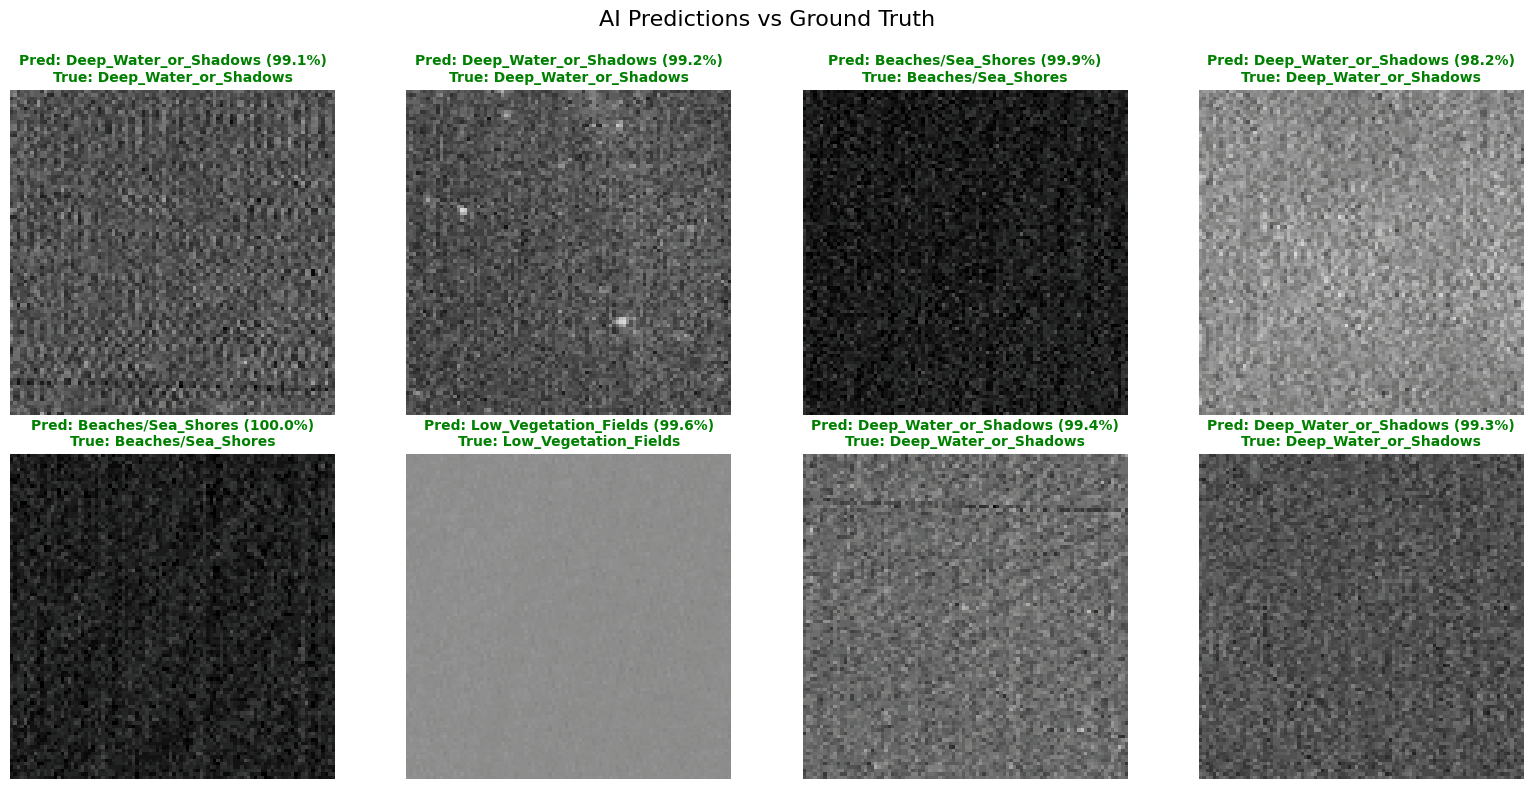

In [36]:
# UPDATED CELL 19: Test the Model on Random Images
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np

# Your new dictionary!
class_names = {
    5: 'Bare_Earth_Exposed_Soil', 
    4: 'Deep_Water_or_Shadows', 
    3: 'Urban_Built_Up',
    2: 'Roads_and_Pavement',
    0: 'Low_Vegetation_Fields',
    1: 'Beaches/Sea_Shores'  
}

classifier.eval()
dataiter = iter(val_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = classifier(images)
    probabilities = F.softmax(outputs, dim=1)
    max_probs, predicted = torch.max(probabilities, 1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()
max_probs = max_probs.cpu()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("AI Predictions vs Ground Truth", fontsize=16)

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

for i, ax in enumerate(axes.flatten()):
    if i < len(images):
        img = inv_normalize(images[i])
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1) 
        
        true_label = class_names[labels[i].item()]
        pred_label = class_names[predicted[i].item()]
        confidence = max_probs[i].item() * 100
        
        ax.imshow(img)
        ax.axis('off')
        color = "green" if true_label == pred_label else "red"
        ax.set_title(f"Pred: {pred_label} ({confidence:.1f}%)\nTrue: {true_label}", 
                     color=color, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


--- CLASSIFICATION REPORT (Precision / Recall / F1-Score) ---
                         precision    recall  f1-score   support

  Low_Vegetation_Fields       0.98      0.99      0.99       128
     Beaches/Sea_Shores       0.94      0.96      0.95       630
     Roads_and_Pavement       0.76      0.78      0.77        92
         Urban_Built_Up       0.83      0.71      0.77       120
  Deep_Water_or_Shadows       0.94      0.90      0.92       439
Bare_Earth_Exposed_Soil       0.64      0.82      0.72        55

               accuracy                           0.91      1464
              macro avg       0.85      0.86      0.85      1464
           weighted avg       0.91      0.91      0.91      1464



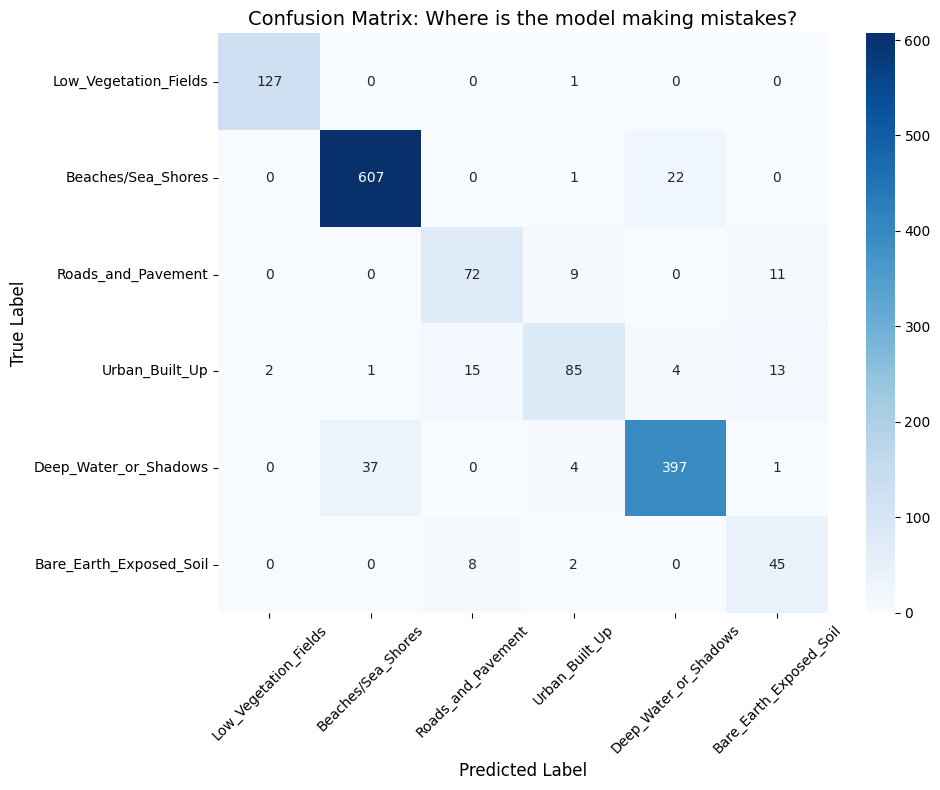

In [37]:
# UPDATED CELL 20: Advanced Metrics (Confusion Matrix & Classification Report)
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

classifier.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = classifier(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy()) # Make sure labels are moved to CPU

# THE FIX: This list MUST be in order of ID 0, 1, 2, 3, 4, 5
class_names_list = [
    'Low_Vegetation_Fields',   # 0
    'Beaches/Sea_Shores',      # 1
    'Roads_and_Pavement',      # 2
    'Urban_Built_Up',          # 3
    'Deep_Water_or_Shadows',   # 4
    'Bare_Earth_Exposed_Soil'  # 5
]

print("\n--- CLASSIFICATION REPORT (Precision / Recall / F1-Score) ---")
print(classification_report(all_labels, all_preds, target_names=class_names_list))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_list, 
            yticklabels=class_names_list)
plt.title("Confusion Matrix: Where is the model making mistakes?", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ======================================================================
#  FINAL OUTPUT MAP - Cartosat Panchromatic Classification Illustration
# ======================================================================
import os, glob, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch
from torchvision import transforms as T
from torchvision.models import resnet18
from collections import Counter

CLASS_NAMES      = ["Low Vegetation","Beaches/Shores","Roads & Pavement",
                    "Urban Built-up","Water/Shadows","Bare Earth"]
CLASS_COLORS_HEX = ["#228B22","#F4A460","#808080","#DC143C","#1E90FF","#D2691E"]

ckpt        = torch.load("models/cartosat_classifier_best.pth", map_location="cpu", weights_only=False)
class_names = ckpt.get("class_names", CLASS_NAMES)
crop_size   = ckpt.get("crop_size", 256)
mean        = ckpt.get("imagenet_mean", [0.485, 0.456, 0.406])
std         = ckpt.get("imagenet_std",  [0.229, 0.224, 0.225])

mdl = resnet18(weights=None)
mdl.fc = torch.nn.Linear(mdl.fc.in_features, len(class_names))
mdl.load_state_dict(ckpt["model_state_dict"])
mdl.eval()
val_acc = ckpt.get("val_acc", "?")
print("Loaded checkpoint  val_acc =", val_acc)

all_patches = sorted(glob.glob(os.path.join("training_patches", "*.png")))
idxs        = np.linspace(0, len(all_patches)-1, min(64, len(all_patches)), dtype=int)
tfm         = T.Compose([T.Resize((crop_size,crop_size)), T.ToTensor(), T.Normalize(mean, std)])

pred_cls, pred_conf, imgs = [], [], []
with torch.no_grad():
    for p in [all_patches[i] for i in idxs]:
        pil   = Image.open(p).convert("RGB")
        probs = torch.softmax(mdl(tfm(pil).unsqueeze(0)), dim=1).numpy()[0]
        pred_cls.append(int(probs.argmax()))
        pred_conf.append(float(probs.max()))
        imgs.append(np.array(pil.resize((128, 128))))

n    = len(imgs)
cols = 8
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.4), facecolor="#0a0e17")
for i, ax in enumerate(axes.ravel()):
    if i < n:
        c     = pred_cls[i]
        conf  = pred_conf[i]
        color = CLASS_COLORS_HEX[c]
        ax.imshow(imgs[i])
        ax.set_title(class_names[c] + "
" + "{:.0%}".format(conf),
                     fontsize=6.5, color=color, fontweight="bold", pad=2)
        for sp in ax.spines.values():
            sp.set_edgecolor(color)
            sp.set_linewidth(2.5)
    ax.axis("off")

patches = [mpatches.Patch(color=c, label=nm)
           for c, nm in zip(CLASS_COLORS_HEX, class_names)]
fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=9,
           framealpha=0.2, facecolor="#0a0e17", edgecolor="#1e4976",
           labelcolor="white", bbox_to_anchor=(0.5, -0.03))
plt.suptitle("Urban Feature Extraction - Cartosat Panchromatic (ResNet18 6-class)",
             color="#38bdf8", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("models/cartosat_classification_illustration.png", dpi=150,
            bbox_inches="tight", facecolor="#0a0e17")
plt.show()
print("Saved: models/cartosat_classification_illustration.png")

cnt = Counter(pred_cls)
print("
-- Predicted Class Distribution --")
for i, nm in enumerate(class_names):
    c = cnt.get(i, 0)
    print("  {:<20s} {:3d} patches  ({:.1f}%)".format(nm, c, 100*c/n))
